In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("data/Summer-Olympic-medals-1976-to-2008.csv",encoding="latin1")

In [43]:
df.shape

(15433, 11)

In [44]:
df.columns

Index(['City', 'Year', 'Sport', 'Discipline', 'Event', 'Athlete', 'Gender',
       'Country_Code', 'Country', 'Event_gender', 'Medal'],
      dtype='object')

In [45]:
df.dtypes

City             object
Year            float64
Sport            object
Discipline       object
Event            object
Athlete          object
Gender           object
Country_Code     object
Country          object
Event_gender     object
Medal            object
dtype: object

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15433 entries, 0 to 15432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          15316 non-null  object 
 1   Year          15316 non-null  float64
 2   Sport         15316 non-null  object 
 3   Discipline    15316 non-null  object 
 4   Event         15316 non-null  object 
 5   Athlete       15316 non-null  object 
 6   Gender        15316 non-null  object 
 7   Country_Code  15316 non-null  object 
 8   Country       15316 non-null  object 
 9   Event_gender  15316 non-null  object 
 10  Medal         15316 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.3+ MB


In [47]:
df.isnull().sum()

City            117
Year            117
Sport           117
Discipline      117
Event           117
Athlete         117
Gender          117
Country_Code    117
Country         117
Event_gender    117
Medal           117
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(117)

In [49]:
df = df.dropna(how="all")

In [50]:
df = df.drop_duplicates()


In [51]:
print("Shape after cleaning:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Shape after cleaning: (15315, 11)
Missing values: 0
Duplicates: 0


In [52]:
# Descriptive Statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,15315,9,Beijing,2042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,15315.0,NaN,NaN,NaN,1993.621678,10.159586,1976.0,1984.0,1996.0,2004.0,2008.0
Sport,15315,28,Aquatics,2210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Discipline,15315,41,Athletics,1523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Event,15315,293,hockey,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Athlete,15315,11337,"PHELPS, Michael",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,15315,2,Men,9387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country_Code,15315,128,USA,1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,15315,127,United States,1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Event_gender,15315,3,M,8816,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
# Unique Values
print("Years:", sorted(df["Year"].unique()))
print("Countries:", df["Country"].nunique())
print("Sports:", df["Sport"].nunique())
print("Disciplines:", df["Discipline"].nunique())
print("Events:", df["Event"].nunique())
print("Athletes:", df["Athlete"].nunique())
print("Medals:", df["Medal"].value_counts())
print("Gender:", df["Gender"].value_counts())

Years: [np.float64(1976.0), np.float64(1980.0), np.float64(1984.0), np.float64(1988.0), np.float64(1992.0), np.float64(1996.0), np.float64(2000.0), np.float64(2004.0), np.float64(2008.0)]
Countries: 127
Sports: 28
Disciplines: 41
Events: 293
Athletes: 11337
Medals: Medal
Bronze    5258
Gold      5041
Silver    5016
Name: count, dtype: int64
Gender: Gender
Men      9387
Women    5928
Name: count, dtype: int64


# Medal Distribution

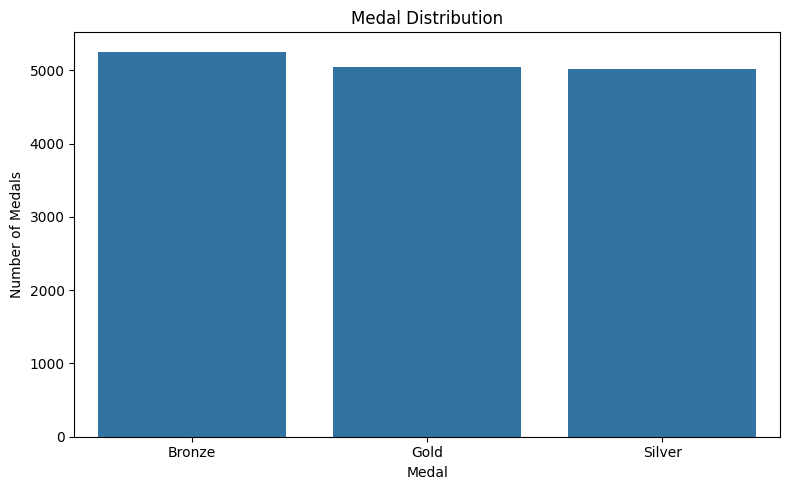

In [54]:
medal_counts = df["Medal"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=medal_counts.index,
    y=medal_counts.values
)

plt.title("Medal Distribution")
plt.xlabel("Medal")
plt.ylabel("Number of Medals")
plt.tight_layout()
plt.show()

# Medals by Olympic Year

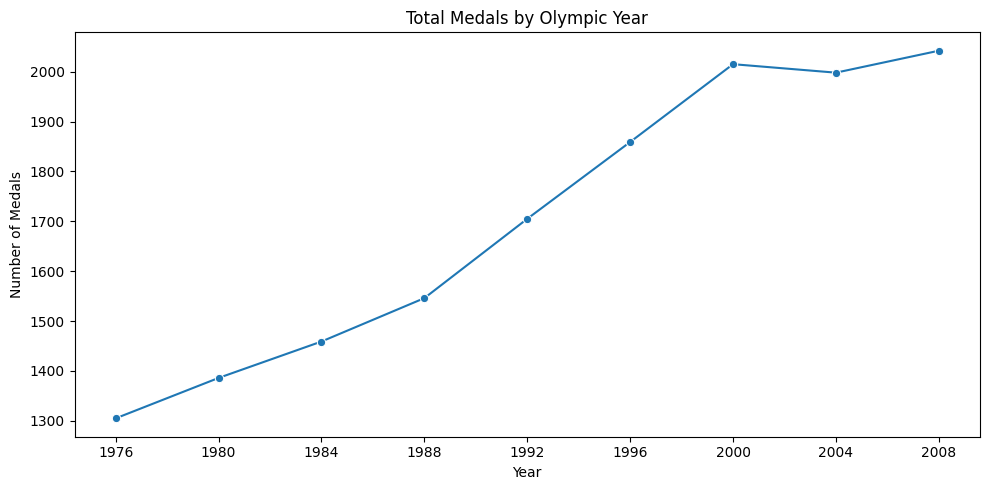

In [55]:
year_medals = df.groupby("Year")["Medal"].count()

plt.figure(figsize=(10, 5))
sns.lineplot(x=year_medals.index, y=year_medals.values, marker="o")

plt.title("Total Medals by Olympic Year")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.xticks(sorted(df["Year"].unique()))
plt.tight_layout()
plt.show()

# Medals by Gender

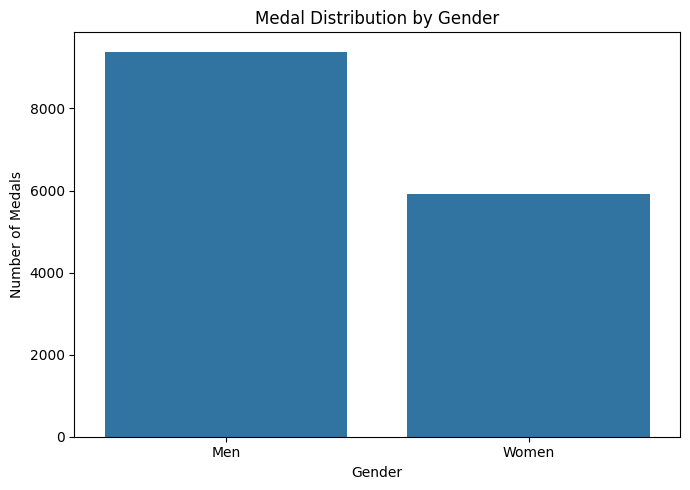

In [56]:
gender_medals = df["Gender"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=gender_medals.index,
    y=gender_medals.values
)

plt.title("Medal Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Medals")
plt.tight_layout()
plt.show()

# Top 10 Countries by Gold Medals

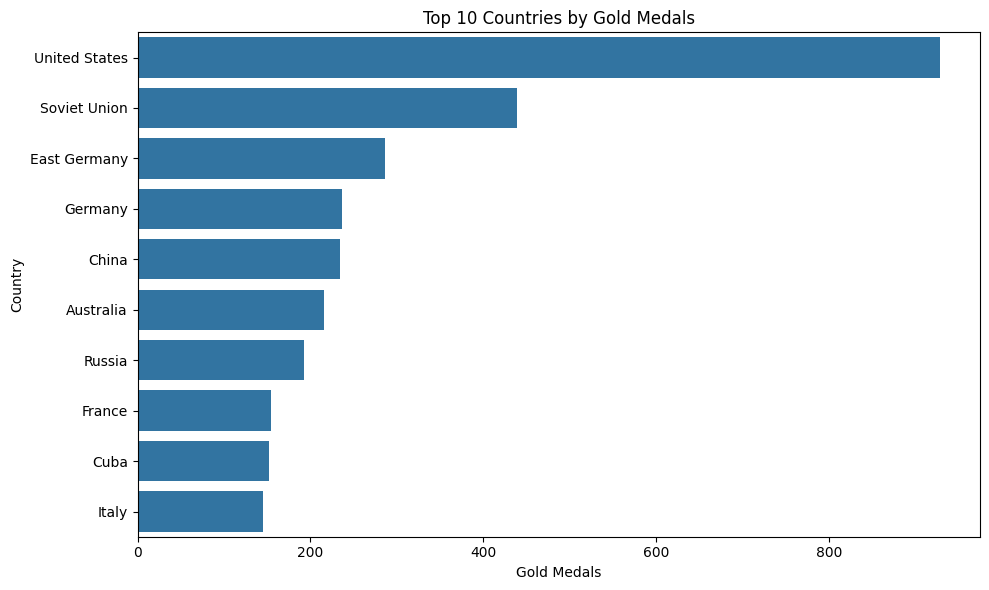

In [57]:
gold_medals = (
    df[df["Medal"] == "Gold"]
    .groupby("Country")["Medal"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=gold_medals.values,
    y=gold_medals.index
)

plt.title("Top 10 Countries by Gold Medals")
plt.xlabel("Gold Medals")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Top 10 Countries by Overall Medals

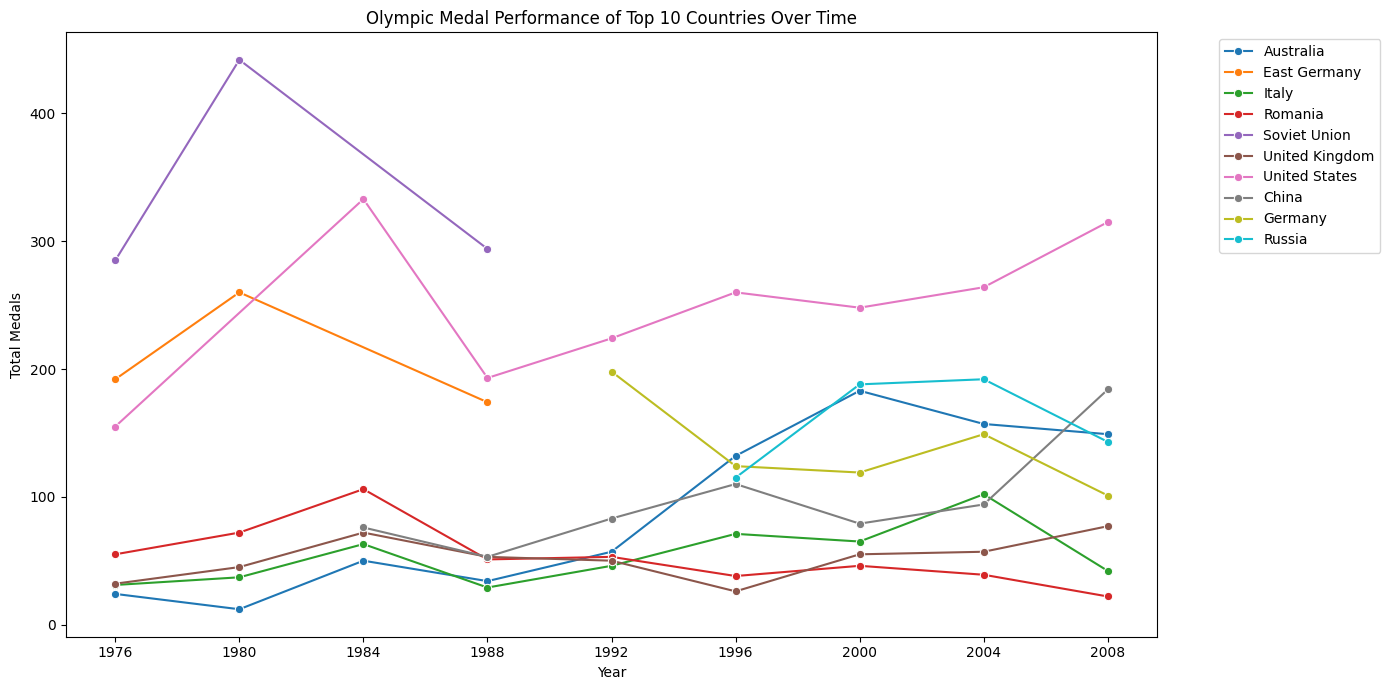

In [58]:
top_countries = (
    df.groupby("Country")["Medal"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .index
)

country_year_medals = (
    df[df["Country"].isin(top_countries)]
    .groupby(["Year", "Country"])
    .size()
    .reset_index(name="Medals")
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=country_year_medals,
    x="Year",
    y="Medals",
    hue="Country",
    marker="o"
)

plt.title("Olympic Medal Performance of Top 10 Countries Over Time")
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.xticks(sorted(df["Year"].unique()))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Top 15 Sports by Total Medals

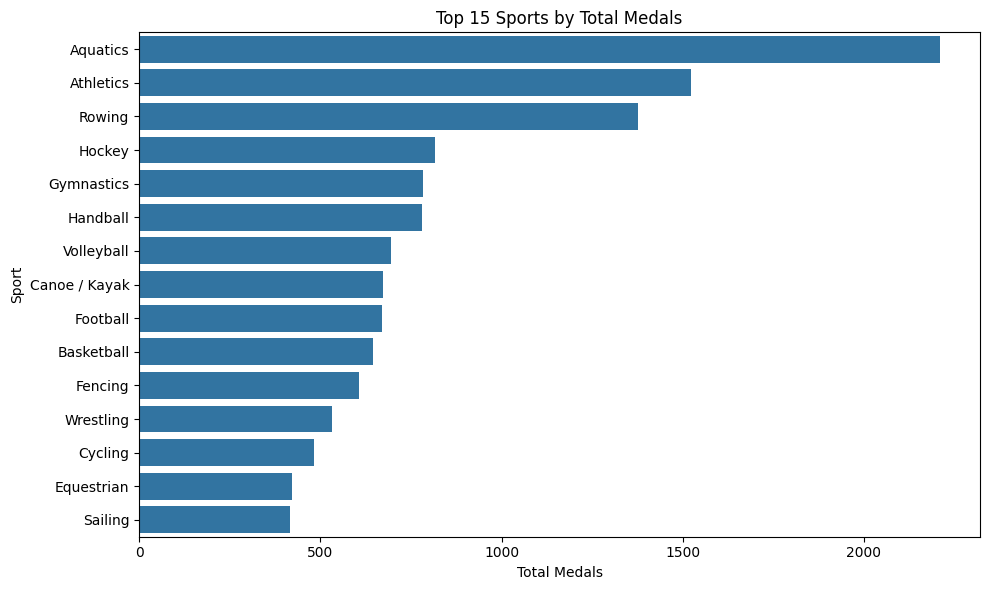

In [59]:
sport_medals = (
    df.groupby("Sport")["Medal"]
    .count()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=sport_medals.values,
    y=sport_medals.index
)

plt.title("Top 15 Sports by Total Medals")
plt.xlabel("Total Medals")
plt.ylabel("Sport")
plt.tight_layout()
plt.show()

# Create early vs recent Olympic periods

In [60]:
early = (
    df[df["Year"] <= 1992]
    .groupby("Country")
    .size()
    .reset_index(name="Early_Medals")
)

recent = (
    df[df["Year"] >= 1996]
    .groupby("Country")
    .size()
    .reset_index(name="Recent_Medals")
)

country_growth = pd.merge(
    early,
    recent,
    on="Country",
    how="inner"
)

country_growth["Medal_Change"] = (
    country_growth["Recent_Medals"] -
    country_growth["Early_Medals"]
)

country_growth["Growth_Percentage"] = (
    (country_growth["Recent_Medals"] -
     country_growth["Early_Medals"])
    / country_growth["Early_Medals"]
) * 100

country_growth.sort_values(
    "Medal_Change",
    ascending=False
).head(15)

,Country,Early_Medals,Recent_Medals,Medal_Change,Growth_Percentage
2,Australia,177,621,444,250.847458
23,Germany,198,493,295,148.989899
11,China,212,467,255,120.283019
67,United States,905,1087,182,20.110497
45,Netherlands,138,290,152,110.144928
6,Brazil,91,227,136,149.450549
1,Argentina,15,138,123,820.000000
15,Cuba,115,234,119,103.478261
57,Spain,120,208,88,73.333333
37,"Korea, South",185,269,84,45.405405


# Visualize the improving countries

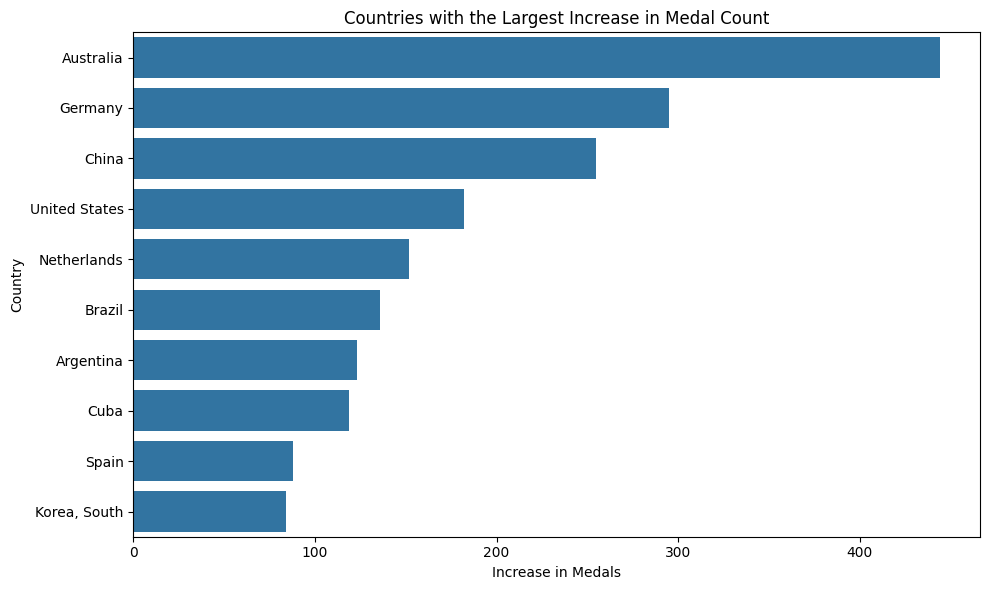

In [61]:
top_improving = (
    country_growth
    .sort_values("Medal_Change", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_improving,
    x="Medal_Change",
    y="Country"
)

plt.title("Countries with the Largest Increase in Medal Count")
plt.xlabel("Increase in Medals")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# Top 10 Countries by Total Medals

In [62]:
top_countries = (
    df.groupby("Country")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

country_sport_top = (
    df[df["Country"].isin(top_countries)]
    .groupby(["Country", "Sport"])
    .size()
    .reset_index(name="Medals")
)

country_sport_top = (
    country_sport_top
    .sort_values(["Country", "Medals"], ascending=[True, False])
)

country_sport_top.head(20)

,Country,Sport,Medals
0,Australia,Aquatics,239
10,Australia,Hockey,145
12,Australia,Rowing,88
15,Australia,Softball,60
7,Australia,Cycling,54
4,Australia,Basketball,48
6,Australia,Canoe / Kayak,31
13,Australia,Sailing,25
2,Australia,Athletics,24
3,Australia,Baseball,24


# Medal Distribution by Sport

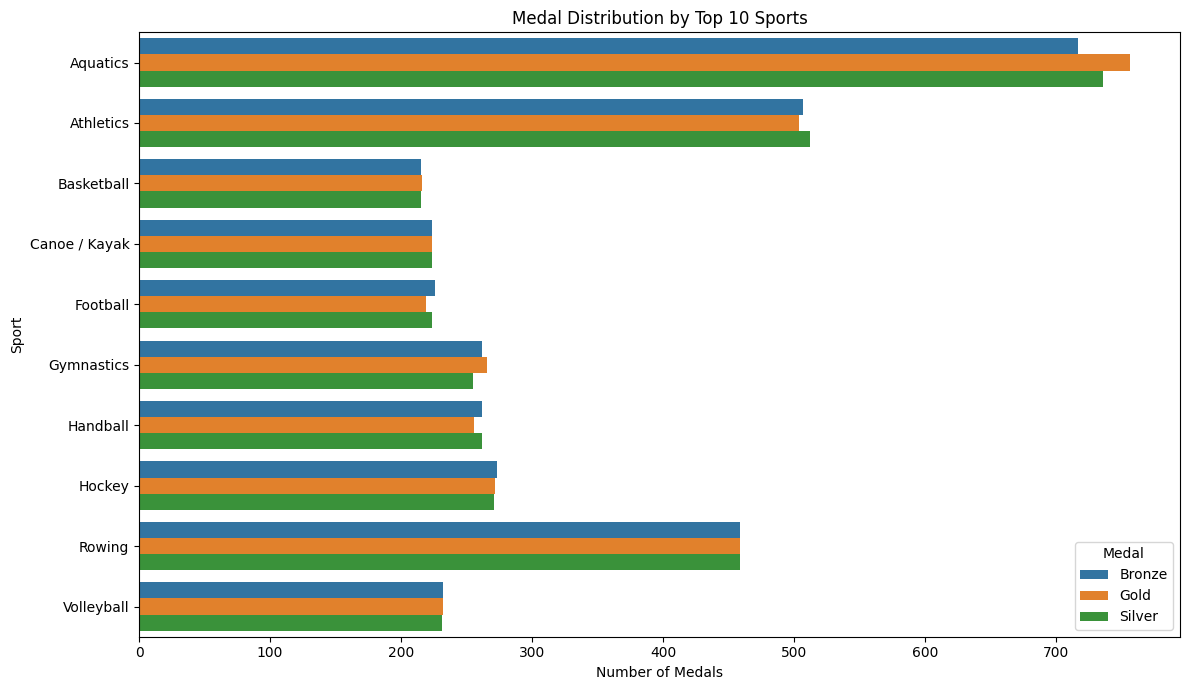

In [63]:
sport_medal_type = (
    df.groupby(["Sport", "Medal"])
    .size()
    .reset_index(name="Count")
)

top_sports = (
    df.groupby("Sport")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

sport_medal_type = sport_medal_type[
    sport_medal_type["Sport"].isin(top_sports)
]

plt.figure(figsize=(12, 7))

sns.barplot(
    data=sport_medal_type,
    x="Count",
    y="Sport",
    hue="Medal"
)

plt.title("Medal Distribution by Top 10 Sports")
plt.xlabel("Number of Medals")
plt.ylabel("Sport")
plt.tight_layout()
plt.show()

# Country–Sport Analysis

In [64]:
country_sport = (
    df.groupby(["Country", "Sport"])
    .size()
    .reset_index(name="Medals")
)

country_sport.sort_values(
    "Medals",
    ascending=False
).head(20)

,Country,Sport,Medals
757,United States,Aquatics,578
759,United States,Athletics,299
17,Australia,Aquatics,239
761,United States,Basketball,192
477,Netherlands,Hockey,159
555,Romania,Rowing,156
225,East Germany,Rowing,146
27,Australia,Hockey,145
772,United States,Rowing,129
560,Russia,Aquatics,125


In [68]:
import os
os.getcwd()

'E:\\All\\Data Analysis\\Projects\\3.Summer Olympics'

In [69]:
df["Year"] = df["Year"].astype(int)

df.to_csv(
    "data/Summer-Olympic-medals-1976-to-2008-clean.csv",
    index=False,
    encoding="utf-8-sig"
)

In [70]:
df.shape

(15315, 11)

In [71]:
import pandas as pd

test = pd.read_csv(
    "data/Summer-Olympic-medals-1976-to-2008-clean.csv",
    encoding="utf-8-sig"
)

print(test.shape)
print(test.head())

(15315, 11)
       City  Year     Sport Discipline           Event  \
0  Montreal  1976  Aquatics     Diving  3m springboard   
1  Montreal  1976  Aquatics     Diving  3m springboard   
2  Montreal  1976  Aquatics     Diving  3m springboard   
3  Montreal  1976  Aquatics     Diving  3m springboard   
4  Montreal  1976  Aquatics     Diving    10m platform   

                    Athlete Gender Country_Code        Country Event_gender  \
0           KÖHLER, Christa  Women          GDR   East Germany            W   
1       KOSENKOV, Aleksandr    Men          URS   Soviet Union            M   
2      BOGGS, Philip George    Men          USA  United States            M   
3  CAGNOTTO, Giorgio Franco    Men          ITA          Italy            M   
4    WILSON, Deborah Keplar  Women          USA  United States            W   

    Medal  
0  Silver  
1  Bronze  
2    Gold  
3  Silver  
4  Bronze  
